# 순환 신경망 기반 감성 분석 (네이버 영화 리뷰)
1. 데이터 준비
2. 모델 구축 및 컴파일
3. 모델 학습
4. 모델 평가
5. 예측
6. 배포 (저장, 재사용)

## 1. 데이터 준비
    1-1. 데이터 로딩
    1-2. 데이터 전처리
    1-3. 데이터 분리 
    1-4. 학습용 데이터 준비
    1-5. 테스트용 데이터준비 

### 1-1. 데이터 로딩

In [67]:
datafile = './data/naver_movie_review.csv'

import pandas as pd
review_df = pd.read_csv(datafile)
review_df.head()


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


### 1-2. 데이터 전처리
- 결측치 제거
- 정제 (한글만 남기고 모두 삭제)
- 중복치 제거
- 형태소 분석기로 토큰화

#### 1-2-1. 결측치 제거

In [68]:
# 결측치 확인(결측치 개수 확인)
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        200000 non-null  int64 
 1   document  199992 non-null  object
 2   label     200000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.6+ MB


In [69]:
# 결측치가 있는 레코드(행) 확인
review_df[review_df.document.isnull()] # 이거 시험에 나옴

,id,document,label
25857,2172111,NaN,1
55737,6369843,NaN,1
110014,1034280,NaN,0
126782,5942978,NaN,0
140721,1034283,NaN,0
155746,402110,NaN,1
157899,5026896,NaN,0
177097,511097,NaN,1


In [70]:
# 결측치 제거
review_df.dropna(inplace=True)

#### 1-2-2. 정제
* 한글과 공백을 제외한 문자는 공백으로 치환하여 제거
* 한글이 없었던 문장은 공백만 남아있게 되므로, 결측치 삭제 처리 진행 필요

In [71]:
import re
import numpy as np

# 한글과 공백 제외하고 모두 공백으로 치환
review_df['clean_doc'] = review_df.document.apply(lambda x: re.sub('[^ ㄱ-ㅣ가-힣]+', ' ', x))

# 문장의 시작 부분에 있는 공백을 ""으로 치환 
review_df.clean_doc = review_df.document.apply(lambda x: re.sub('^ +', ' ', x))

# 빈 문자열("")은 결측치로 수정
review_df.clean_doc = review_df.clean_doc.replace('', np.nan)

review_df.head()

,id,document,label,clean_doc
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0,아 더빙.. 진짜 짜증나네요 목소리
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나
2,10265843,너무재밓었다그래서보는것을추천한다,0,너무재밓었다그래서보는것을추천한다
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...


In [72]:
# 결측치 확인
review_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199992 entries, 0 to 199999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         199992 non-null  int64 
 1   document   199992 non-null  object
 2   label      199992 non-null  int64 
 3   clean_doc  199992 non-null  object
dtypes: int64(2), object(2)
memory usage: 7.6+ MB


In [73]:
review_df[review_df.clean_doc.isnull()]

,id,document,label,clean_doc


In [74]:
# 결측치 제거
review_df.dropna(inplace=True)

In [75]:
review_df.clean_doc.isnull().sum()

0

#### 1-2-3. 중복치 제거

In [76]:
# 중복치 확인
review_df.clean_doc.duplicated().sum()

5449

In [77]:
review_df[review_df.clean_doc.duplicated()]

,id,document,label,clean_doc
1058,5890638,4,0,4
1097,2062443,쵝오,1,쵝오
1248,3502685,최고,1,최고
1483,775332,최고,1,최고
1707,8009134,재밌다,1,재밌다
...,...,...,...,...
199767,4032953,최고,1,최고
199775,632708,괜찮음..,1,괜찮음..
199841,8097768,2년이 지나도 잊혀지지 않는 소중한 드라마.,1,2년이 지나도 잊혀지지 않는 소중한 드라마.
199861,9301787,단순 액션물과 마찬가지로 남는 것 없는 팝콘 무비. 역시 짐 캐리 최고의 영화는 트...,0,단순 액션물과 마찬가지로 남는 것 없는 팝콘 무비. 역시 짐 캐리 최고의 영화는 트...


In [78]:
# 중복치 제거
review_df.drop_duplicates(subset=['clean_doc'], inplace=True)

In [79]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 194543 entries, 0 to 199999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         194543 non-null  int64 
 1   document   194543 non-null  object
 2   label      194543 non-null  int64 
 3   clean_doc  194543 non-null  object
dtypes: int64(2), object(2)
memory usage: 7.4+ MB


#### 1-2-4. 토큰화

In [80]:
# 형태소 분석기 적용 (Okt, Komoran 등)
from konlpy.tag import Okt
t = Okt()

from tqdm import tqdm
tqdm.pandas()

stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다','..','...']
review_df['tokens'] = review_df.clean_doc.progress_apply(lambda x: [word for word in t.morphs(x) if word not in stopwords])

100%|██████████| 194543/194543 [08:39<00:00, 374.70it/s]


In [81]:
review_list = []
for review in tqdm(list(review_df.clean_doc)):
    review_list.append([token for token in t.morphs(review)])

# review_df['tokens'] = review_list

100%|██████████| 194543/194543 [09:51<00:00, 328.94it/s]


In [82]:
review_df.head()

,id,document,label,clean_doc,tokens
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0,아 더빙.. 진짜 짜증나네요 목소리,"[아, 더빙, 진짜, 짜증나네요, 목소리]"
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,"[흠, 포스터, 보고, 초딩, 영화, 줄, ...., 오버, 연기, 조차, 가볍지,..."
2,10265843,너무재밓었다그래서보는것을추천한다,0,너무재밓었다그래서보는것을추천한다,"[너, 무재, 밓었, 다그, 래서, 보는것을, 추천, 다]"
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,"[교도소, 이야기, 구먼, 솔직히, 재미, 없다, 평점, 조정]"
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,"[사이, 몬페, 그, 익살스런, 연기, 돋보였던, 영화, !, 스파이더맨, 에서, ..."


### 1-3. 데이터 분리
* 정답 데이터의 분포 확인 -> 학습용 데이터와 테스트 데이터로 분리 시 비율 유지 (stratify=y)

In [83]:
# label 컬럼의 값별 데이터 수 확인
# review_df.label.value_counts()
review_df.groupby('label').size()

label
0    97375
1    97168
dtype: int64

<Axes: xlabel='label'>

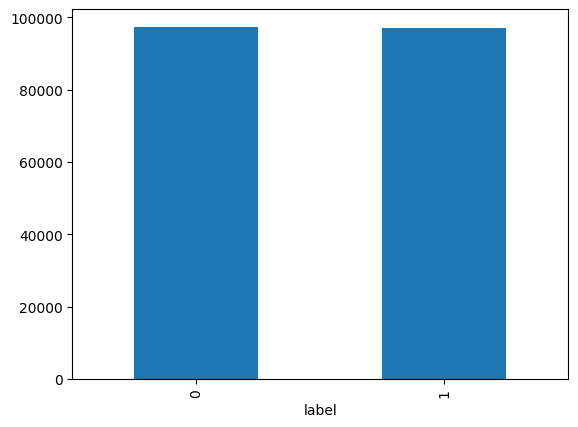

In [84]:
# 막대그래프로 그려보기
# review_df.label.value_counts().plot(kind='bar')
review_df.groupby('label').size().plot(kind='bar')

In [85]:
# 입력 데이터와 정답데이터 추출  (list)
review_list = list(review_df.tokens) 
label_list = list(review_df.label)
len(review_list), len(label_list)

(194543, 194543)

In [86]:
# 학습 데이터와 테스트 데이터 분리
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(review_list, label_list, test_size=0.1)
len(train_X), len(test_X), len(train_y), len(test_y)

(175088, 19455, 175088, 19455)

### 1-4. 학습 데이터 준비
    1-4-1. Integer Encoding을 위한 tokenizer 생성
    1-4-2. 입력 데이터 Integer Encoding
    1-4-3. 입력 데이터 Padding
    1-4-4. 정답 데이터 원핫인코딩

#### 1-4-1. Integer Encoding을 위한 tokenizer 생성
* num_words = 사용할 단어 수(vocab_size) + 1 (0은 OOV에 할당)

In [87]:
# 단어 수 제한없이 Tokenizer 생성하여 단어 수 확인
from tensorflow.keras.preprocessing.text import Tokenizer
test_tokenizer = Tokenizer()
test_tokenizer.fit_on_texts(train_X)
len(test_tokenizer.word_index)

115351

In [88]:
# 등장 빈도수를 threshold로 설정하여 버릴 단어가 차지하는 비율 확인
from mylib.my_utils import rare_word_status
threshold = 2
rare_word_status(threshold, test_tokenizer.word_counts.items())

전체 단어 : 115,351개 2,184,719번
희귀 단어(등장빈도 2번 미만) : 62,825개 62,825번
희귀 단어 비율 : 단어 수 54.46%, 빈도수 2.88%
희귀 단어를 뺀 단어 수 :  52,526개 97.12%


In [89]:
# 단어 수를 제한하여 tokenizer 생성
num_vocab = 30000
num_words = num_vocab + 1
tokenizer = Tokenizer(num_words=num_words)
tokenizer.fit_on_texts(train_X)
len(tokenizer.word_counts), tokenizer.num_words

(115351, 30001)

#### 1-4-2. 입력 데이터 Integer Encoding
* 제한된 단어에만 index를 부여하므로, 희귀 단어로만 구성된 review는 단어가 0이 되므로 결측치에 해당 -> 결측치 제거

In [90]:
# 입력 데이터 Integer Encoding
encoded_train_X = tokenizer.texts_to_sequences(train_X)
print(len(encoded_train_X))
print(encoded_train_X[:5])

175088
[[8, 227, 619, 201, 18, 10, 82, 1206, 19861, 131, 10690, 8429, 302, 18, 1213, 4, 4071, 4372, 133, 8, 17, 1144, 24, 272, 34, 1, 242, 651, 18, 456, 4072, 651, 2761, 2984, 17962, 1152, 777, 266, 25483, 15, 72, 25484, 10691, 43, 107, 78, 1], [409, 211, 1575, 73, 10, 177], [184, 751, 26, 217, 39, 19862, 1, 8158, 6836, 2, 1477, 19863, 34, 1], [880, 1565, 5223, 1952, 1565, 975, 1748, 103, 1390, 16, 5766, 16, 11258, 7661, 56, 15184, 7, 2615, 10220, 930, 13282, 103, 345, 522, 9, 24, 16, 975, 1748, 21, 2, 12], [11834, 3354, 212, 4, 9391, 13, 17963, 1306, 538, 2027, 4929, 9810]]


In [91]:
# 길이가 0인 리뷰의 index 추출: train_X의 결측치 인덱스를 알아야 train_y의 해당 인덱스도 지울 수 있음
null_index = [index for index, review in enumerate(encoded_train_X) if len(review) < 1]
len(null_index)

531

In [92]:
# 길이가 0인 리뷰가 있는 경우, 길이가 1 이상인 리뷰로 학습데이터 재구성
# 1. list comprehension
new_train_X = [review for index, review in enumerate(encoded_train_X) if index not in null_index]
new_train_y = [label for index, label in enumerate(encoded_train_X) if index not in null_index]

In [93]:
# 2. for문
new_train_X = []
new_train_y = []

for i in range(len(encoded_train_X)):
    if len(encoded_train_X[i]):
        new_train_X.append(encoded_train_X[i])
        new_train_y.append(train_y[i])

len(new_train_X), len(new_train_y)

(174557, 174557)

#### 1-4-3. 입력 데이터 padding
* 입력 데이터의 길이(max_len)를 정하여 padding

array([[<Axes: title={'center': '0'}>]], dtype=object)

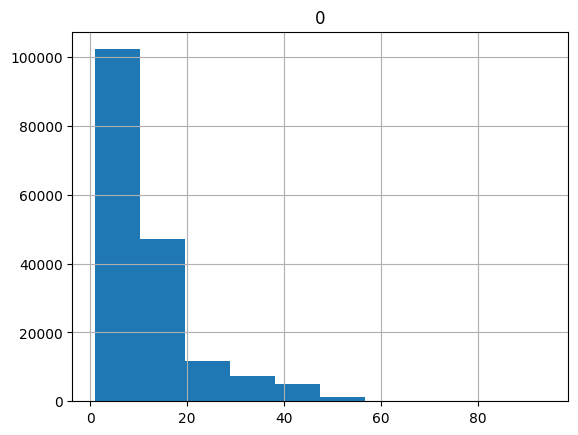

In [94]:
# 리뷰 길이 분포 확인 (히스토그램 그려보기)
len_df = pd.DataFrame([len(review) for review in new_train_X])
len_df.hist()

In [95]:
# 최대, 최소, 평균 등 정보 확인
len_df.describe()

,0
count,174557.000000
mean,11.853578
std,9.656049
min,1.000000
25%,6.000000
50%,9.000000
75%,14.000000
max,94.000000


In [96]:
import importlib
import mylib
importlib.reload(mylib.my_utils)

<module 'mylib.my_utils' from 'd:\\Lecture\\TextMining26\\mylib\\my_utils.py'>

In [97]:
from mylib.my_utils import below_threshold_len_from_list
# 길이가 max_len 이하인 데이터의 비중 확인
max_len = 60
below_threshold_len_from_list(max_len, new_train_X)

길이가 60 이하인 텍스트의 비율 : 99.9851%


In [98]:
# max_len 길이로 입력 데이터 padding
from tensorflow.keras.preprocessing.sequence import pad_sequences
train_X = pad_sequences(new_train_X, maxlen=max_len)
len(train_X), train_X[:2]

(174557,
 array([[    0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     8,   227,   619,   201,    18,
            10,    82,  1206, 19861,   131, 10690,  8429,   302,    18,
          1213,     4,  4071,  4372,   133,     8,    17,  1144,    24,
           272,    34,     1,   242,   651,    18,   456,  4072,   651,
          2761,  2984, 17962,  1152,   777,   266, 25483,    15,    72,
         25484, 10691,    43,   107,    78,     1],
        [    0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
           409,   211,  1575,    73,    10,   177]]))

#### 1-4-4. 정답 데이터 one-hot encoding

In [99]:
from tensorflow.keras.utils import to_categorical
train_y = to_categorical(new_train_y)
len(train_y), train_y[:2]

(174557,
 array([[1., 0.],
        [1., 0.]], dtype=float32))

### 1-5. 테스트 데이터 준비
    1-5-1. 입력 데이터 Integer Encoding (결측치제거) 
    1-5-2. 입력 데이터 padding
    1-5-3. 정답 데이터 one-hot encoding

In [100]:
# 입력 데이터 Integer Encoding
encoded_test_X = tokenizer.texts_to_sequences(test_X)
len(encoded_test_X), encoded_test_X[:2]

(19455, [[1571, 2], [91, 1292, 2514, 217, 86, 58]])

In [101]:
# 길이가 0인 리뷰의 index 추출 -> 있으면 길이가 1 이상인 리뷰만으로 테스트 데이터 재구성 
null_index = [index for index, review in enumerate(encoded_test_X) if len(review) < 1]
len(null_index)

76

In [102]:
new_test_X = [review for index, review in enumerate(encoded_test_X) if index not in null_index]
new_test_y = [label for index, label in enumerate(test_y) if index not in null_index]
len(new_test_X), len(new_test_y)

(19379, 19379)

In [103]:
# 입력 데이터 padding
test_X = pad_sequences(new_test_X, maxlen=max_len)
len(test_X), test_X[:2]

(19379,
 array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0, 1571,    2],
        [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,   91,
         1292, 2514,  217,   86,   58]]))

In [104]:
# 정답 데이터 one-hot encoding
test_y = to_categorical(new_test_y)
len(test_y), test_y[:2]

(19379,
 array([[0., 1.],
        [0., 1.]], dtype=float32))

## 2. 모델 구축 및 컴파일

In [105]:
# 모델 설계
from tensorflow.keras.layers import Embedding, LSTM, Dense
# Embedding layer의 파라미터
num_features = num_words
embedding_dim = 32
input_length = max_len

rnn_nodes = 32

dense_nodes = 16
output_nodes = 2

rnn_model = [
    Embedding(num_features, embedding_dim, input_length=input_length),
    LSTM(rnn_nodes),
    Dense(dense_nodes, activation='tanh'),
    Dense(output_nodes, activation='softmax')
]

In [106]:
# 모델 생성
from tensorflow.keras.models import Sequential
model = Sequential(rnn_model)
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 60, 32)            960032    
                                                                 
 lstm_1 (LSTM)               (None, 32)                8320      
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dense_3 (Dense)             (None, 2)                 34        
                                                                 
Total params: 968,914
Trainable params: 968,914
Non-trainable params: 0
_________________________________________________________________


In [107]:
# 학습 설계: 생성한 모델에 학습 관련 하이퍼파라미터를 설정
from tensorflow.keras.optimizers import RMSprop
model.compile(loss='binary_crossentropy', metrics='accuracy', optimizer=RMSprop(learning_rate=0.001))

In [108]:
# EarlyStopping, ModelCheckpoint callback 함수 설정
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
es = EarlyStopping(monitor='val_loss', mode='min', patience=3, verbose=1)
checkpoint_filepath = './model/best_model.h5'
mc = ModelCheckpoint(checkpoint_filepath, monitor='val_loss', mode='min', save_best_only=True)

## 3. 모델 학습

In [109]:
# 모델 학습
model.fit(train_X, train_y, epochs=20, batch_size=128, validation_split=0.1, callbacks=[es, mc])

Epoch 1/20
1228/1228 [==============================] - 18s 14ms/step - loss: 0.3854 - accuracy: 0.8254 - val_loss: 0.3370 - val_accuracy: 0.8534
Epoch 2/20
1228/1228 [==============================] - 19s 16ms/step - loss: 0.3150 - accuracy: 0.8663 - val_loss: 0.3246 - val_accuracy: 0.8586
Epoch 3/20
1228/1228 [==============================] - 18s 14ms/step - loss: 0.2932 - accuracy: 0.8764 - val_loss: 0.3133 - val_accuracy: 0.8631
Epoch 4/20
1228/1228 [==============================] - 16s 13ms/step - loss: 0.2733 - accuracy: 0.8868 - val_loss: 0.3105 - val_accuracy: 0.8669
Epoch 5/20
1228/1228 [==============================] - 16s 13ms/step - loss: 0.2568 - accuracy: 0.8953 - val_loss: 0.3076 - val_accuracy: 0.8693
Epoch 6/20
1228/1228 [==============================] - 16s 13ms/step - loss: 0.2431 - accuracy: 0.9023 - val_loss: 0.3114 - val_accuracy: 0.8695
Epoch 7/20
1228/1228 [==============================] - 16s 13ms/step - loss: 0.2320 - accuracy: 0.9076 - val_loss: 0.3193 -

## 4. 모델 평가

In [119]:
# 저장된 모델 로딩하여, 테스트 데이터로 평가
model.load_weights(checkpoint_filepath)
test_loss, test_acc = model.evaluate(test_X, test_y)
print(f'정확도 : {test_acc * 100:.3f}%')

606/606 [==============================] - 2s 3ms/step - loss: 0.3124 - accuracy: 0.8647
정확도 : 86.470%


In [120]:
# predict로 테스트 데이터의 예측값 구하기
import numpy as np
results = model.predict(test_X)
print(results[:1])
labels = ['부정', '긍정']
user_outputs = [labels[np.argmax(result)] for result in results]
print(user_outputs[:10])

606/606 [==============================] - 1s 2ms/step
[[0.20791525 0.7920848 ]]
['긍정', '긍정', '긍정', '부정', '부정', '부정', '부정', '긍정', '부정', '긍정']


In [121]:
# sklearn의 classification_report()로 평가 결과 확인
from sklearn.metrics import classification_report
pred_labels = [0, 1]
preds = [pred_labels[np.argmax(result)] for result in results]
print(classification_report(new_test_y, preds))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      9727
           1       0.88      0.85      0.86      9652

    accuracy                           0.86     19379
   macro avg       0.87      0.86      0.86     19379
weighted avg       0.87      0.86      0.86     19379



## 5. 예측

In [122]:
# 입력된 리뷰에 대한 긍부정 판단 함수
def analyze_semtiment(review):
    # 데이터 준비 : 정제
    # 한국어 형태소 분석
    tokens = [word for word in t.morphs(review)]
    
    # Integer Encoding
    encoded_tokens = tokenizer.texts_to_sequences([tokens])

    # padding
    X = pad_sequences(encoded_tokens)

    # 예측
    results = model.predict(X, verbose=0)
    labels = ['부정', '긍정']
    index = np.argmax(results[0])
    user_outputs = labels[index]
    return user_outputs, results[0][index]

In [114]:
# 함수 테스트
reviews = [
    '이 영화 개꿀잼 ㅋㅋㅋ',
    '하품만 나온다',
    '이 영화 핵노잼 ㅠㅠ',
    '이딴게 영화냐 ㅉㅉ',
    '와 개쩐다',
    '감독 뭐하는 놈이냐',
    '정말 세계관 최강자들의 영화다'
]

for review in reviews:
    user_outputs, prob = analyze_semtiment(review)
    print(f'{review} --> {user_outputs}({prob*100:.2f}%)')

이 영화 개꿀잼 ㅋㅋㅋ --> 긍정(98.39%)
하품만 나온다 --> 부정(99.71%)
이 영화 핵노잼 ㅠㅠ --> 부정(99.97%)
이딴게 영화냐 ㅉㅉ --> 부정(99.99%)
와 개쩐다 --> 긍정(92.14%)
감독 뭐하는 놈이냐 --> 부정(98.95%)
정말 세계관 최강자들의 영화다 --> 긍정(60.82%)


## 6. 배포 (모델 저장 및 재사용)
    6-1. 모델 저장
    6-2. SentimentAnalyzer 클래스 구현
        *  저장된 모델 로딩 및 사용

### 6-1. 모델 저장 

In [123]:
# t(Okt 객체) -> Okt 클래스 활용하여 생성
# keras 학습 모델 저장 
model.save('./model/sa_movie_model.keras')

In [124]:
# Integer Encoding을 위한 파이썬 객체 직렬화 (encoder) : tokenizer
import joblib 
joblib.dump(tokenizer, './model/sa_movie_encoder.pkl')

['./model/sa_movie_encoder.pkl']

### 6-2. SentimentAnalyzer 클래스 구현
- 객체 생성 시 예측 모델, Integer Encoder 로딩
- 한국어 형태소 분석기 정의
- 입력된 리뷰의 긍부정 판단 함수

In [125]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from konlpy.tag import Okt
import joblib
import numpy as np

class SentimentAnalyzer:
    def __init__(self, model_file, encoder_file):
        self.model = load_model(model_file)
        self.encoder = joblib.load(encoder_file)
        self.korean_tokenizer = Okt().morphs
    
    def analyze_semtiment(self, review):
        # 데이터 준비 : 정제
        # 한국어 형태소 분석
        tokens = [word for word in self.korean_tokenizer(review)]
        
        # Integer Encoding
        encoded_tokens = self.encoder.texts_to_sequences([tokens])

        # padding
        X = pad_sequences(encoded_tokens, maxlen=self.model.input_shape[1])

        # 예측
        results = self.model.predict(X, verbose=0)
        labels = ['부정', '긍정']
        index = np.argmax(results[0])
        user_outputs = labels[index]
        return user_outputs, results[0][index]


In [126]:
sa = SentimentAnalyzer('./model/sa_movie_model.keras', './model/sa_movie_encoder.pkl')

# 함수 테스트
reviews = [
    '이 영화 개꿀잼 ㅋㅋㅋ',
    '하품만 나온다',
    '이 영화 핵노잼 ㅠㅠ',
    '이딴게 영화냐 ㅉㅉ',
    '와 개쩐다',
    '감독 뭐하는 놈이냐',
    '정말 세계관 최강자들의 영화다'
]

for review in reviews:
    user_outputs, prob = sa.analyze_semtiment(review)
    print(f'{review} --> {user_outputs}({prob*100:.2f}%)')

이 영화 개꿀잼 ㅋㅋㅋ --> 긍정(99.35%)
하품만 나온다 --> 부정(99.96%)
이 영화 핵노잼 ㅠㅠ --> 부정(99.98%)
이딴게 영화냐 ㅉㅉ --> 부정(100.00%)
와 개쩐다 --> 긍정(96.66%)
감독 뭐하는 놈이냐 --> 부정(99.69%)
정말 세계관 최강자들의 영화다 --> 긍정(69.60%)
